# UCS 547 — Accelerated Data Science  
## Lab Assignment 2  
### Introduction to CUDA, Colab, and GPU Basics

**Name:** Tanishq  
**Course:** UCS 547 – Accelerated Data Science  
**Assignment:** Lab Assignment 2  
**Topic:** CUDA Fundamentals, GPU Commands, and CPU vs NumPy Performance





---



### Q1. Identify !, % and %% used in cells in Google Colab.

Google Colab supports special commands:
!  → run Linux terminal commands  
%  → single-line magic command  
%% → multi-line cell magic command


In [1]:
# ! command (shell command)
!nvidia-smi


Mon Feb 16 06:18:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# % command (single line magic)
%time sum(range(1000000))


CPU times: user 18.6 ms, sys: 113 µs, total: 18.7 ms
Wall time: 18.7 ms


499999500000

In [3]:
%%time
# %% command (cell magic)
total = 0
for i in range(1000000):
    total += i
print(total)


499999500000
CPU times: user 105 ms, sys: 210 µs, total: 105 ms
Wall time: 106 ms


Result:
! runs shell commands,
% runs single-line magic commands,
%% applies magic to entire cell.
These are useful for running system commands and measuring execution time in Colab.




---



### Q2. Identify all key nvidia-smi commands with multiple options.

nvidia-smi is used to monitor GPU usage, memory, temperature, and running processes.
It provides detailed information about GPU status and performance.


In [4]:
!nvidia-smi


Mon Feb 16 06:20:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!nvidia-smi -L


GPU 0: Tesla T4 (UUID: GPU-84f3d6f6-5694-d916-470a-b0b88ac42b68)


In [6]:
!nvidia-smi --query-gpu=name,memory.total,memory.used,utilization.gpu --format=csv


name, memory.total [MiB], memory.used [MiB], utilization.gpu [%]
Tesla T4, 15360 MiB, 0 MiB, 0 %


In [7]:
!nvidia-smi -q



==============NVSMI LOG==============

Timestamp                                 : Mon Feb 16 06:20:19 2026
Driver Version                            : 580.82.07
CUDA Version                              : 13.0

Attached GPUs                             : 1
GPU 00000000:00:04.0
    Product Name                          : Tesla T4
    Product Brand                         : NVIDIA
    Product Architecture                  : Turing
    Display Mode                          : Requested functionality has been deprecated
    Display Attached                      : Yes
    Display Active                        : Disabled
    Persistence Mode                      : Disabled
    Addressing Mode                       : None
    MIG Mode
        Current                           : N/A
        Pending                           : N/A
    Accounting Mode                       : Disabled
    Accounting Mode Buffer Size           : 4000
    Driver Model
        Current                           : N/

Result:
nvidia-smi displays GPU information such as memory usage, temperature, and running processes.
Options like -L, -q, and --query-gpu provide detailed monitoring and diagnostics of GPU hardware.




---



### Q3. Debug common CUDA errors (zero output, incorrect indexing, PTX errors)

Common CUDA errors include:
- Zero output due to missing cudaMemcpy or kernel sync
- Incorrect indexing causing wrong results
- PTX or compilation errors due to wrong architecture


In [8]:
%%writefile q3_debug.cu
#include <iostream>
using namespace std;

__global__ void testKernel(int *arr) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    arr[i] = i;
}

int main() {
    int N = 8;
    int size = N * sizeof(int);

    int h_arr[8];
    int *d_arr;

    cudaMalloc(&d_arr, size);

    testKernel<<<1,8>>>(d_arr);
    cudaDeviceSynchronize();

    cudaMemcpy(h_arr, d_arr, size, cudaMemcpyDeviceToHost);

    for(int i=0;i<8;i++)
        cout<<h_arr[i]<<" ";

    cudaFree(d_arr);
    return 0;
}


Writing q3_debug.cu


In [9]:
!nvcc q3_debug.cu -o q3_debug
!./q3_debug


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
0 1 2 3 4 5 6 7 

Result:
The program demonstrates correct thread indexing and memory transfer.
Common CUDA errors such as zero output can be fixed by ensuring proper memory copy and synchronization.




---



### Q4. Write a CUDA C/C++ program to demonstrate GPU kernel execution and thread indexing.

a. Launch CUDA kernel using 1 block and 8 threads  
b. Each thread prints: Hello from GPU thread <global_thread_id>  
c. global_thread_id = blockIdx.x * blockDim.x + threadIdx.x  
d. Clearly separate host (CPU) and device (GPU) code


In [10]:
%%writefile q4_threads.cu
#include <stdio.h>

// -------- GPU KERNEL (device code) --------
__global__ void helloKernel() {
    int global_thread_id = blockIdx.x * blockDim.x + threadIdx.x;
    printf("Hello from GPU thread %d\n", global_thread_id);
}

// -------- CPU HOST CODE --------
int main() {

    printf("Launching kernel...\n");

    // 1 block, 8 threads
    helloKernel<<<1, 8>>>();

    cudaDeviceSynchronize();

    printf("Kernel finished.\n");

    return 0;
}


Writing q4_threads.cu


In [11]:
!nvcc q4_threads.cu -o q4_threads
!./q4_threads


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Launching kernel...
Hello from GPU thread 0
Hello from GPU thread 1
Hello from GPU thread 2
Hello from GPU thread 3
Hello from GPU thread 4
Hello from GPU thread 5
Hello from GPU thread 6
Hello from GPU thread 7
Kernel finished.


Result:
The CUDA kernel launched with 1 block and 8 threads.
Each GPU thread printed its global thread ID.
This demonstrates how threads are indexed and executed in parallel on the GPU.
Host code runs on CPU while kernel runs on GPU.




---



### Q5. Write a CUDA program to demonstrate host and device memory separation.

a. Create integer array of size 5 on host (CPU)  
b. Allocate memory on device (GPU) using cudaMalloc()  
c. Copy data host → device using cudaMemcpy()  
d. Launch kernel where GPU threads print values  
e. Copy data back device → host and print on CPU


In [12]:
%%writefile q5_memory.cu
#include <stdio.h>

// -------- GPU kernel --------
__global__ void printFromGPU(int *d_arr) {
    int i = threadIdx.x;
    printf("GPU thread %d sees value %d\n", i, d_arr[i]);
}

// -------- CPU host code --------
int main() {

    int h_arr[5] = {10, 20, 30, 40, 50};
    int *d_arr;

    int size = 5 * sizeof(int);

    // allocate GPU memory
    cudaMalloc(&d_arr, size);

    // copy host → device
    cudaMemcpy(d_arr, h_arr, size, cudaMemcpyHostToDevice);

    // launch kernel
    printFromGPU<<<1,5>>>(d_arr);
    cudaDeviceSynchronize();

    // copy back device → host
    int result[5];
    cudaMemcpy(result, d_arr, size, cudaMemcpyDeviceToHost);

    printf("\nValues copied back to CPU:\n");
    for(int i=0;i<5;i++)
        printf("%d ", result[i]);

    cudaFree(d_arr);
    return 0;
}


Writing q5_memory.cu


In [13]:
!nvcc q5_memory.cu -o q5_memory
!./q5_memory


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
GPU thread 0 sees value 10
GPU thread 1 sees value 20
GPU thread 2 sees value 30
GPU thread 3 sees value 40
GPU thread 4 sees value 50

Values copied back to CPU:
10 20 30 40 50 

Result:
Host memory and device memory were allocated separately.
Data was copied from CPU to GPU using cudaMemcpy.
GPU threads accessed and printed values from device memory.
Data was then copied back to CPU and printed successfully.




---



### Q6. Compare CPU times of Python List/Tuple with NumPy arrays.

This experiment compares execution time for element-wise addition using:
1. Python list
2. Python tuple
3. NumPy array

The goal is to observe performance differences in CPU computation.


In [15]:
import time
import numpy as np

N = 1_000_000

# -------- LIST --------
a_list = list(range(N))
b_list = list(range(N))

start = time.time()
c_list = [a_list[i] + b_list[i] for i in range(N)]
list_time = (time.time() - start) * 1000


# -------- TUPLE --------
a_tuple = tuple(range(N))
b_tuple = tuple(range(N))

start = time.time()
c_tuple = tuple(a_tuple[i] + b_tuple[i] for i in range(N))
tuple_time = (time.time() - start) * 1000


# -------- NUMPY --------
a_np = np.arange(N)
b_np = np.arange(N)

start = time.time()
c_np = a_np + b_np
numpy_time = (time.time() - start) * 1000


print("List time (ms):", list_time)
print("Tuple time (ms):", tuple_time)
print("NumPy time (ms):", numpy_time)


List time (ms): 93.61410140991211
Tuple time (ms): 125.76842308044434
NumPy time (ms): 3.2219886779785156


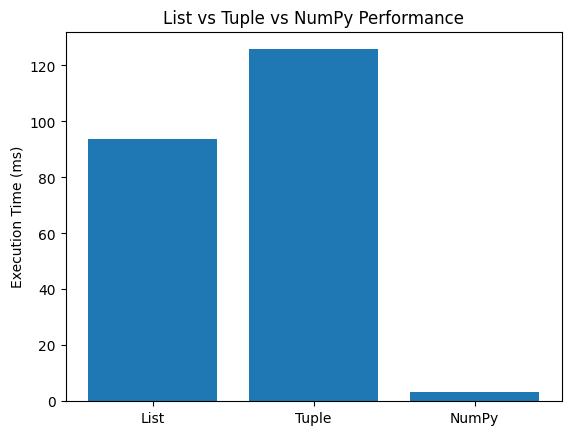

In [16]:
import matplotlib.pyplot as plt

labels = ['List', 'Tuple', 'NumPy']
times = [list_time, tuple_time, numpy_time]

plt.bar(labels, times)
plt.ylabel("Execution Time (ms)")
plt.title("List vs Tuple vs NumPy Performance")
plt.show()


Result:
Execution time comparison shows that NumPy arrays perform significantly faster
than Python lists and tuples for large-scale numerical operations.
This is because NumPy uses optimized C-based vectorized computation.




---

